<a href="https://colab.research.google.com/github/urshubham08/SQL8/blob/main/used_cars_predict_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder , StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [ ]:
# load dataset with pandas
df = pd.read_csv('/content/used_cars.csv')

In [ ]:
# extract first ten rows
df.head(10)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"
5,Acura,ILX 2.4L,2016,"136,397 mi.",Gasoline,2.4 Liter,F,Silver,Ebony.,None reported,NaN,"$14,798"
6,Audi,S3 2.0T Premium Plus,2017,"84,000 mi.",Gasoline,292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,Blue,Black,None reported,Yes,"$31,000"
7,BMW,740 iL,2001,"242,000 mi.",Gasoline,282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,A/T,Green,Green,None reported,Yes,"$7,300"
8,Lexus,RC 350 F Sport,2021,"23,436 mi.",Gasoline,311.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,6-Speed A/T,Black,Black,None reported,Yes,"$41,927"
9,Tesla,Model X Long Range Plus,2020,"34,000 mi.",NaN,534.0HP Electric Motor Electric Fuel System,A/T,Black,Black,None reported,Yes,"$69,950"


In [ ]:
# extract tail ten rows
df.tail(10)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
3999,BMW,X6 xDrive40i,2020,"34,000 mi.",Gasoline,335.0HP 3.0L Straight 6 Cylinder Engine Gasoli...,8-Speed A/T,White,Brown,None reported,Yes,"$59,335"
4000,Subaru,Ascent Touring 7-Passenger,2021,"32,250 mi.",Gasoline,260.0HP 2.4L 4 Cylinder Engine Gasoline Fuel,A/T,Black,Black,At least 1 accident or damage reported,Yes,"$36,000"
4001,Volkswagen,Routan SE,2011,"194,000 mi.",Gasoline,283.0HP 3.6L V6 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Gray,At least 1 accident or damage reported,Yes,"$3,500"
4002,Mercedes-Benz,AMG GLS 63 4MATIC,2023,"2,000 mi.",Hybrid,603.0HP 4.0L 8 Cylinder Engine Gasoline/Mild E...,9-Speed A/T,Gray,Beige,None reported,Yes,"$175,000"
4003,Mercedes-Benz,E-Class E 300 4MATIC,2018,"53,705 mi.",Gasoline,241.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,A/T,Black,Black,At least 1 accident or damage reported,Yes,"$25,900"
4004,Bentley,Continental GT Speed,2023,714 mi.,Gasoline,6.0L W12 48V PDI DOHC Twin Turbo,8-Speed Automatic with Auto-Shift,C / C,Hotspur,None reported,Yes,"$349,950"
4005,Audi,S4 3.0T Premium Plus,2022,"10,900 mi.",Gasoline,349.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,"$53,900"
4006,Porsche,Taycan,2022,"2,116 mi.",NaN,Electric,Automatic,Black,Black,None reported,NaN,"$90,998"
4007,Ford,F-150 Raptor,2020,"33,000 mi.",Gasoline,450.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,A/T,Blue,Black,None reported,Yes,"$62,999"
4008,BMW,X3 xDrive30i,2020,"43,000 mi.",Gasoline,248.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,A/T,Gray,Brown,At least 1 accident or damage reported,Yes,"$40,000"


In [ ]:
# extract sample data
df.sample(10)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
1094,Jaguar,F-PACE 25t Premium,2019,"29,000 mi.",Gasoline,247.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,A/T,White,Black,None reported,Yes,"$34,500"
2607,Chevrolet,Traverse High Country,2020,"56,247 mi.",Gasoline,3.6L V6 24V GDI DOHC,9-Speed Automatic,Stone Gray Metallic,Jet Black,None reported,Yes,"$39,244"
3767,Ford,E350 Super Duty XLT,2010,"248,000 mi.",E85 Flex Fuel,255.0HP 5.4L 8 Cylinder Engine Flex Fuel Capab...,A/T,Silver,Beige,At least 1 accident or damage reported,Yes,"$14,000"
887,Mercedes-Benz,Sprinter 3500XD High Roof,2021,"33,300 mi.",Diesel,188.0HP 3.0L V6 Cylinder Engine Diesel Fuel,7-Speed A/T,White,Black,None reported,Yes,"$45,000"
1642,Audi,A4 2.0T Titanium Premium,2019,"7,300 mi.",Gasoline,188.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,White,Gray,None reported,Yes,"$27,900"
3502,Ford,Mustang Mach-E GT,2022,"8,000 mi.",NaN,480.0HP Electric Motor Electric Fuel System,1-Speed A/T,Blue,Black,None reported,Yes,"$60,999"
705,Dodge,Ram 1500 Quad Cab,2002,"179,000 mi.",Gasoline,245.0HP 5.9L 8 Cylinder Engine Gasoline Fuel,A/T,Black,Black,At least 1 accident or damage reported,Yes,"$6,500"
1041,Jeep,Gladiator Freedom,2021,"30,630 mi.",Gasoline,3.6 Liter,Automatic,Hydro Blue Pearlcoat,Black,None reported,NaN,"$39,998"
1950,Audi,Q7 3.0T Prestige,2018,"70,773 mi.",Gasoline,333.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,A/T,White,Black,None reported,Yes,"$30,950"
870,Kia,Telluride SX,2020,"55,400 mi.",Gasoline,291.0HP 3.8L V6 Cylinder Engine Gasoline Fuel,8-Speed A/T,Green,White,NaN,NaN,"$36,500"


In [ ]:
# check how many rows and columns existed in Dataset
df.shape

(4009, 12)

In [ ]:
# check data types for all columns
df.dtypes

,0
brand,object
model,object
model_year,int64
milage,object
fuel_type,object
engine,object
transmission,object
ext_col,object
int_col,object
accident,object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


In [ ]:
# check count , mean , Standard deviation and five point summary
df.describe()

,model_year
count,4009.000000
mean,2015.515590
std,6.104816
min,1974.000000
25%,2012.000000
50%,2017.000000
75%,2020.000000
max,2024.000000


In [ ]:
# check how many columns exist in DataSet
df.columns

Index(['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'clean_title',
       'price'],
      dtype='object')

In [ ]:
# contain all numerical columns in one variable
num_col = df.select_dtypes(include = 'number').columns
num_col

Index(['model_year'], dtype='object')

In [ ]:
# contain all categorical columns in one variable
cat_col = df.select_dtypes(include = 'object').columns
cat_col

Index(['brand', 'model', 'milage', 'fuel_type', 'engine', 'transmission',
       'ext_col', 'int_col', 'accident', 'clean_title', 'price'],
      dtype='object')

In [ ]:
# now i check null values
df.isnull().sum()

,0
brand,0
model,0
model_year,0
milage,0
fuel_type,170
engine,0
transmission,0
ext_col,0
int_col,0
accident,113


In [ ]:
# check presented null value in percentage
(df.isnull().sum() / len(df))* 100

,0
brand,0.000000
model,0.000000
model_year,0.000000
milage,0.000000
fuel_type,4.240459
engine,0.000000
transmission,0.000000
ext_col,0.000000
int_col,0.000000
accident,2.818658


In [ ]:
# check duplicate values
df.duplicated().sum()

np.int64(0)

In [ ]:
# check total unique values
df.nunique().sum()

np.int64(8069)

In [ ]:
# check the total number of categorical columns
cat_col.value_counts().sum()

np.int64(11)

In [ ]:
# check the total number of numerical columns
num_col.value_counts().sum()

np.int64(1)

In [ ]:
# DATASET CLEANING

In [ ]:
# in this dataset duplicated is not exist but for the steps i should drop duplicates
df.drop_duplicates()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"
...,...,...,...,...,...,...,...,...,...,...,...,...
4004,Bentley,Continental GT Speed,2023,714 mi.,Gasoline,6.0L W12 48V PDI DOHC Twin Turbo,8-Speed Automatic with Auto-Shift,C / C,Hotspur,None reported,Yes,"$349,950"
4005,Audi,S4 3.0T Premium Plus,2022,"10,900 mi.",Gasoline,349.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,"$53,900"
4006,Porsche,Taycan,2022,"2,116 mi.",NaN,Electric,Automatic,Black,Black,None reported,NaN,"$90,998"
4007,Ford,F-150 Raptor,2020,"33,000 mi.",Gasoline,450.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,A/T,Blue,Black,None reported,Yes,"$62,999"


In [ ]:
# now clean the missing values
df.isnull().sum()
# we have three columns who contains null values so we just feel all three columns
# fuel_type
# accident
# clean_title

,0
brand,0
model,0
model_year,0
milage,0
fuel_type,170
engine,0
transmission,0
ext_col,0
int_col,0
accident,113


In [ ]:
# first is fuel_type column who contains 170 null values
df['fuel_type'].dtypes
df['fuel_type'].isnull().sum()
df['fuel_type'].value_counts(dropna = False)
df['fuel_type'] = df['fuel_type'].fillna(df['fuel_type'].mode()[0])
df['fuel_type'].isnull().sum()

np.int64(0)

In [ ]:
# second is accident column who contains 113 null values
df['accident'].dtypes
df['accident'].isnull().sum()
df['accident'].value_counts(dropna = False)
df['accident'] = df['accident'].fillna(df['accident'].mode()[0])
df['accident'].isnull().sum()

np.int64(0)

In [ ]:
# third is clean_title column who contains 596 null values
# i drop this columns because this column contain only yes value
df = df.drop('clean_title', axis = 1)

In [ ]:
# now check all columns
df.info()
(df.isnull().sum() / len(df)) * 100
df.duplicated().sum()
df.shape
# all null values are clear

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     4009 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      4009 non-null   object
 10  price         4009 non-null   object
dtypes: int64(1), object(10)
memory usage: 344.7+ KB


(4009, 11)

In [ ]:
# SO NOW OUR DATAFRAME IS FULLY CLEANED AND PROCESSED...NOW WE CAN MOVE ON THE VISUALIZATION PART

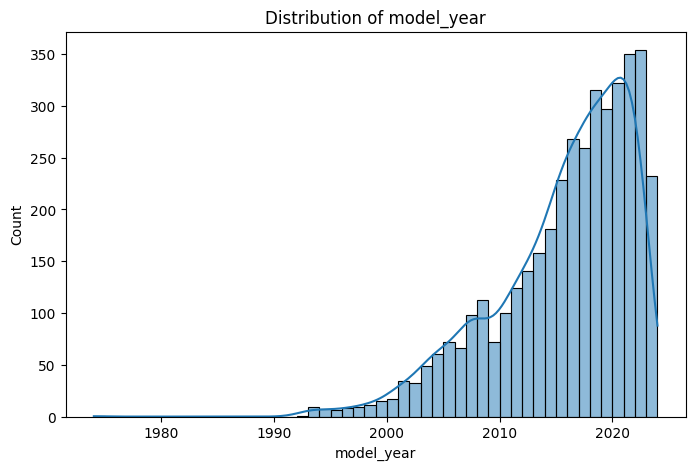

In [ ]:
# Distribution of every numerical column
for i in num_col:
  plt.figure(figsize = (8,5))
  sns.histplot(df[i],kde = True)
  plt.title(f'Distribution of {i}')
  plt.show()

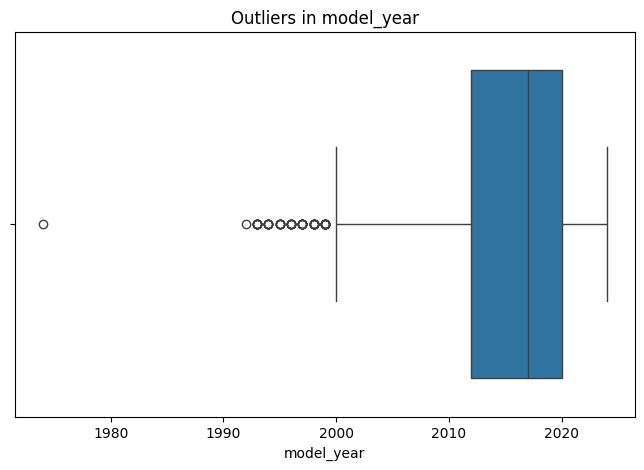

In [ ]:
# Now detect outlier's
for o in num_col:
  plt.figure(figsize = (8,5))
  sns.boxplot(x = df[o])
  plt.title(f'Outliers in {o}')
  plt.show()

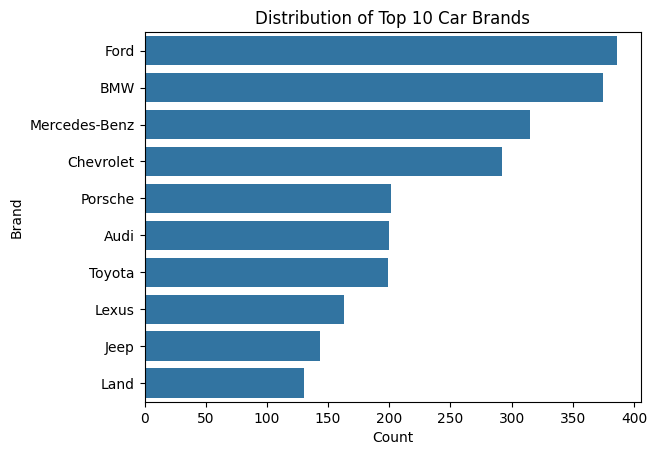

In [ ]:
# Brand distribution — only top 10
top_brand = df["brand"].value_counts().head(10)

sns.barplot(x=top_brand.values, y=top_brand.index)
plt.title("Distribution of Top 10 Car Brands")
plt.xlabel("Count")
plt.ylabel("Brand")
plt.show()

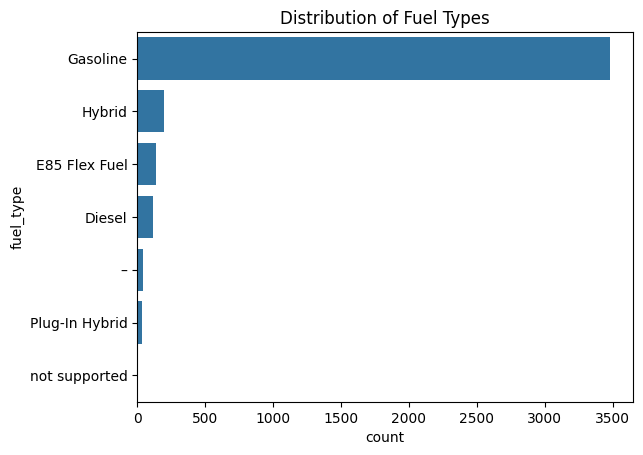

In [ ]:
# Fuel type distribution
sns.countplot(
    data=df,
    y="fuel_type",
    order=df["fuel_type"].value_counts().index
)
plt.title("Distribution of Fuel Types")
plt.show()

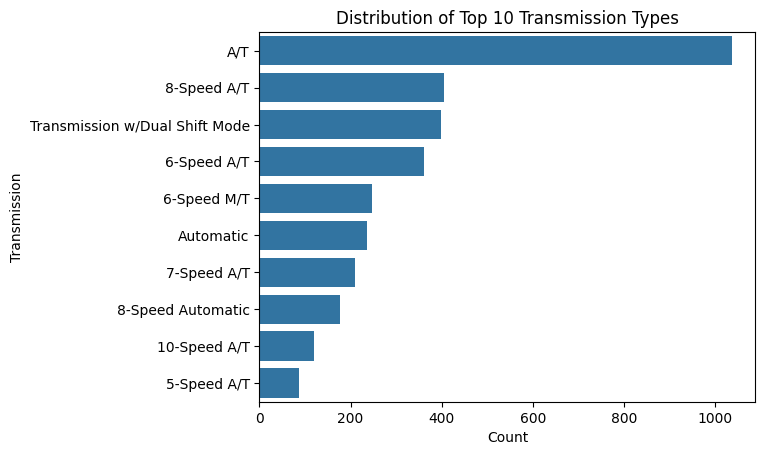

In [ ]:
# Transmission distribution — top 10
top_transmission = df["transmission"].value_counts().head(10)

sns.barplot(x=top_transmission.values, y=top_transmission.index)
plt.title("Distribution of Top 10 Transmission Types")
plt.xlabel("Count")
plt.ylabel("Transmission")
plt.show()

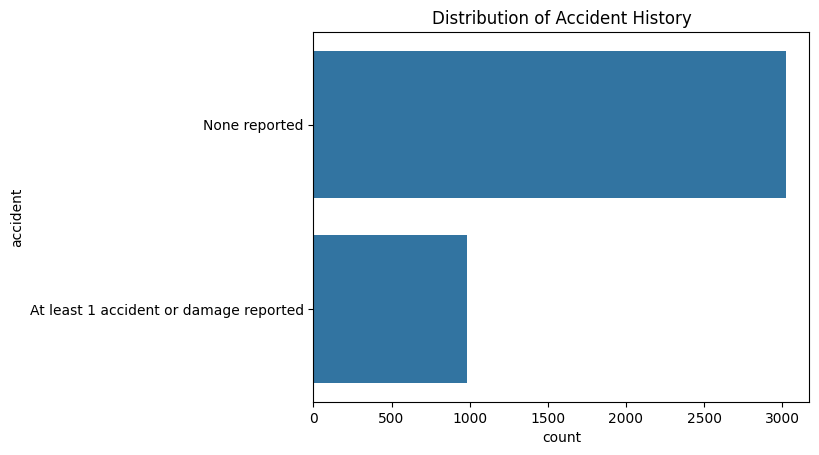

In [ ]:
# Accident history distribution
sns.countplot(
    data=df,
    y="accident",
    order=df["accident"].value_counts().index
)
plt.title("Distribution of Accident History")
plt.show()

In [ ]:
df['price'] = df['price'].str.replace(r"[^0-9]", "", regex=True).astype(int)

In [ ]:
df['milage'] = df['milage'].str.replace(r"[^0-9]", "", regex=True).astype(int)

In [ ]:
df[['price','milage']].dtypes

,0
price,int64
milage,int64


In [ ]:
X = df.drop('price',axis = 1)
y = df['price']

In [ ]:
Num_Col = X.select_dtypes(include = 'number').columns
Cat_Col = X.select_dtypes(exclude = 'number').columns

In [ ]:
scaler = StandardScaler()
scaler_data = scaler.fit_transform(df[Num_Col])
scaled_df = pd.DataFrame(scaler_data , columns = scaler.get_feature_names_out())

In [ ]:
scaled_df

,model_year,milage
0,-0.412118,-0.262336
1,0.898486,-0.573255
2,1.062312,-0.809820
3,-0.084467,0.462467
4,0.898486,-1.049579
...,...,...
4004,1.226137,-1.224010
4005,1.062312,-1.029212
4006,1.062312,-1.197198
4007,0.734661,-0.606569


In [ ]:
encoder = OneHotEncoder(sparse_output = False)
encoded_data = encoder.fit_transform(df[Cat_Col])
encoded_df = pd.DataFrame(encoded_data , columns = encoder.get_feature_names_out())

In [ ]:
encoded_df

,brand_Acura,brand_Alfa,brand_Aston,brand_Audi,brand_BMW,brand_Bentley,brand_Bugatti,brand_Buick,brand_Cadillac,brand_Chevrolet,...,int_col_Very Light Cashmere,int_col_WHITE,int_col_Walnut,int_col_Whisper Beige,int_col_White,int_col_White / Brown,int_col_Yellow,int_col_–,accident_At least 1 accident or damage reported,accident_None reported
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4004,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4005,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4006,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4007,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
X_preprocessed = pd.concat([scaled_df,encoded_df],axis = 1)

In [ ]:
X_train , X_test , y_train , y_test = train_test_split(X_preprocessed , y , test_size = 0.2,random_state = 42)

In [ ]:
model = LinearRegression()
model.fit(X_train , y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
r2_score(y_test,y_pred)

0.06776375801717827